<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/notebooks/nemotron_omni_parse_doc_intelligence_cookbook_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="http://developer.download.nvidia.com/compute/machine-learning/frameworks/nvidia_logo.png" align="right" width="100px"/>

# All-modality document AI with Nemotron Parse + Nemotron 3 Nano Omni

> **You do not need a GPU to run this notebook.** Every model call goes to NVIDIA's hosted catalog endpoint at https://build.nvidia.com. All you need is a free `NVIDIA_API_KEY`. The Setup section below walks you through it.

## 1. Combining two Nemotron models for document analysis



This notebook pairs two NVIDIA models into a document analysis pipeline that handles every modality you'll find in a real PDF. The main model is **Nemotron 3 Nano Omni** (`nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`), a multimodal reasoning model that both reads pictures on the page and answers questions about the whole document. **Nemotron Parse** (`nvidia/nemotron-parse`) handles the spatial anchoring, so Nano Omni can focus on one region at a time and cite the exact page and phrase its answer came from.

### 1.1. Models and their roles

| Role                          | Model                                                       | Mode                              |
| ----------------------------- | ----------------------------------------------------------- | --------------------------------- |
| Architect (layout parser)            | `nvidia/nemotron-parse`                                     | forced `markdown_bbox` tool call (`temperature=0.0`) |
| Specialist (picture classification + transcription)  | `nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`             | non-thinking vision calls (`reasoning="off"`, `top_k=1`; `temperature=0.0` for classification, `0.2` for transcription) |
| Reasoning Engine (final Question and Answer mode)   | `nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`             | Thinking (`reasoning="on"`, `temperature=0.6`, `top_p=0.95`) |


We run the pipeline against four pages picked from three different public PDFs from the [MMLongBench-Doc](https://arxiv.org/pdf/2407.01523) dataset:

* [a Pew Research report](https://huggingface.co/datasets/yubo2333/MMLongBench-Doc/resolve/main/documents/05-03-18-political-release.pdf)
* [a social-media analytics deck](https://huggingface.co/datasets/yubo2333/MMLongBench-Doc/resolve/main/documents/measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf)
* [a graduate-studies brochure](https://huggingface.co/datasets/yubo2333/MMLongBench-Doc/resolve/main/documents/GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf)

Each page stresses a different content modality that a single VLM cannot handle alone:



| Modality | Source | Why it needs Nemotron Parse | Image |
| --- | --- | --- | --- |
| Chart | Pew Research, p. 5 | A stacked-bar chart with eight policy rows. Parse isolates the bar-graph region, so Nano Omni's transcription is a clean markdown table instead of a screenshot caption. | ![Chart](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/chart_pew_research.png) |
| Multi-picture page | Social-media report, p. 11 | Three Facebook-post screenshots side by side. Without Parse's bbox split, the QA call cannot tell which post is *the Disneyland post*. | ![Multi-picture page](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/social_media_report_p11.png) |
| Infographic | Social-media report, p. 20 | A dense pixel-only demographic panel. Parse draws the panel boundary; Nano Omni lists every number inside. | ![Infographic](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/infographic_p20.png) |
| Structured table | Graduate Studies brochure, p. 11 | A two-column programme table. Parse surfaces it as LaTeX-tabular text, so no vision call is needed to read it. | ![Structured table](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/graduate_studies_brochure_p11.png) |

### 1.2. Image detail

![Chart — Pew Research, p. 5](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/chart_pew_research.png)
*Chart — Pew Research, p. 5: A stacked-bar chart with eight policy rows.*

![Multi-picture page — Social-media report, p. 11](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/social_media_report_p11.png)
*Multi-picture page — Social-media report, p. 11: Three Facebook-post screenshots side by side.*

![Infographic — Social-media report, p. 20](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/infographic_p20.png)
*Infographic — Social-media report, p. 20: A dense pixel-only demographic panel.*

![Structured table — Graduate Studies brochure, p. 11](https://raw.githubusercontent.com/andandandand/practical-computer-vision/3dbdff64cb448ca0679357424b3f45c464750f6e/images/graduate_studies_brochure_p11.png)
*Structured table — Graduate Studies brochure, p. 11: A two-column programme table.*

The result is page-cited, phrase-quoted answers that you can check against the page image.


### 1.3. The roles of Nemotron Parse 1.2 and Nemotron 3 Nano Omni



Our pipeline uses two models hosted through NVIDIA Inference Microservices for their specialties. We create a team of
experts assembled around **one unified spatial context**:

* **`nvidia/nemotron-parse`, the Spatial Anchor.**  A light, deterministic
  vision-language model that reads every page's layout.  It returns
  every block's **type** (`Title`, `Text`, `Table`, `List-item`,
  `Picture`, ...), **bounding box**, and **reading order** in one
  call.  This is the spatial anchoring the rest of the pipeline
  relies on.

* **`nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`, the Transcriber.**  Every `Picture` parse identifies becomes one Nano
  Omni call that first *classifies* the image (`Infographic`,
  `Bar Graph`, `Line Graph`, `Smartphone Screenshot`, ...) and then
  *transcribes* it with a prompt tailored to that sub-type.  A single
  "describe this image" prompt is too generic: a bar chart needs its
  table extracted; a UI screenshot needs its labels read in reading
  order; an infographic needs its panel structure preserved.  We call

* **`nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`, the Reasoning
  Engine.**  The *same* model, now reading the assembled document
  context (text blocks in reading order, picture transcriptions
  inlined at the picture's spatial position on the page).  It answers
  your question, cites the page it came from, and quotes the
  supporting phrase verbatim.

Here is the pipeline at a glance:

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/nemotron-parse-omni-pipeline.png?raw=true)



#### 1.3.1. Why pair Nemotron Parse with Nano Omni? Why not Nano Omni alone?

Nemotron Parse helps us build a pipeline for Nano Omni that reduces token consumption and increases accuracy.

Nano Omni is multimodal and handles a single picture with skill. The
moment you move from *one picture* to *a real page*, four structural
problems appear. Each surfaces on a different page in our four-page
demo set, and each is what Parse's spatial layer solves:

1. **Tables and headers need structure.** On the
   Graduate-Studies brochure page, a two-column programme/duration
   table sits inside a glossy marketing layout. Parse emits it as a
   `Table` block with a LaTeX-tabular body, so the Reasoning Engine
   reads the cells as text and **no vision call is needed** to
   answer *"which programme has the longest time period?"*.

2. **A chart region needs isolation before transcription.** On the
   Pew Research page, a stacked bar chart about Trump-confidence
   sits next to four prose paragraphs. Parse draws one `Picture`
   bbox with sub-type `Bar Graph`; Nano Omni receives the chart
   crop on its own and returns a clean eight-row markdown table,
   instead of a mixed caption that averages pixels across chart and
   body copy.

3. **Multi-picture pages bleed together.** A real document page
   tends to hold more than one picture. Page 11 of the social-media
   report packs **three separate Facebook-post screenshots** (Red
   Bull, National Geographic, Disneyland) in a single row. Handing
   that whole page to Nano Omni and asking *"how many likes does
   the Disneyland post have?"* makes the model juggle *which* card
   it is reading while it tries to read it. Parse cuts the page
   into its three `Picture` bounding boxes as a first step, so Nano Omni
   sees one clean crop at a time and has no need to guess which
   neighbour the question was about.

4. **Citations need anchors.** "The answer is on page 20" has value
   when you can point at the exact block. Parse gives every piece
   of content a `bbox` (bounding box) + reading-order index, so an answer can cite
   `(p. 20)` *and* quote the exact phrase that supports it. The
   reader can confirm both on the original page image through
   visual inspection.

Two design levers do the heavy lifting inside the pipeline:

1. **Divide and conquer on every `Picture`.** One class in, many
   kinds of picture transcriptions out.
2. **Spatial-context weave.** Parse's reading-order bboxes let us
   interleave each picture's transcription at the exact position it
   occupies on the page. The Reasoning Engine reads charts *in the
   flow of* their surrounding prose, not as a footnote.

Because the Specialist and the Reasoning Engine are the **same
model**, the description an infographic receives on page 20 sits in
the same representational dialect the question-answering call
expects.

> ### 📓 Colab adaptation notes
>
> This notebook has been adapted from the original cookbook to run on **Google Colab**. Key changes:
> 1. **API key** — read from **Colab Secrets** (the 🔑 icon in the left sidebar) instead of a local `.env` file.
> 2. **File paths** — `DOC_DIR` and `OUTPUT_DIR` now live under `/content/...` (Colab's default working directory) instead of a `REPO_ROOT/data/...` layout.
> 3. **Removed**: `python-dotenv`, the `uv`/`pip` fallback shell logic, and the `REPO_ROOT` parent-directory walk.
>
> ### ⚠️ Action required before you run
>
> 1. In Colab, click the **🔑 key icon** in the left sidebar to open *Secrets*.
> 2. Click **+ Add new secret**, name it exactly `NVIDIA_API_KEY`, and paste your key (`nvapi-...`).
> 3. Toggle **Notebook access** ON for this secret.
> 4. (Optional) GPU is **not** required — every model call hits the hosted endpoint at `integrate.api.nvidia.com`. A CPU runtime is fine.

## 2. Setup and prerequisites

We need an extra Python package on top of what Colab ships with:

| Package | Why we need it | Pre-installed on Colab? |
| --- | --- | --- |
| `pymupdf` (`fitz`) | render PDF pages to pixels | ❌ install required |


In [ ]:
# Colab: pymupdf is the only runtime dep not pre-installed.
# (requests, pillow, pandas are part of the default Colab image.)
!pip install --quiet pymupdf
print("[setup] OK -- runtime deps ready.")

[setup] OK -- runtime deps ready.


### Get your free `NVIDIA_API_KEY` to test hosted NVIDIA Inference Microservice (NIM) endpoints

1. Open the model page on **build.nvidia.com**:
   <https://build.nvidia.com/nvidia/nemotron-3-nano-omni-30b-a3b-reasoning>
2. Sign in (or create a free NVIDIA Developer account, there is no credit card requirement).
3. Click **API Keys** in the top-right of the model page.
![](https://github.com/andandandand/practical-computer-vision/blob/main/images/UserInterface_blurred.png?raw=true)

![](https://raw.githubusercontent.com/andandandand/practical-computer-vision/65446169a4c3769100f1cebf9148b5f4114fbf15/images/GenerateAPIKey.png)

Generate a new key and copy it (it starts with `nvapi-`).
4. **In Colab:** click the **🔑 key icon** in the left sidebar, click **+ Add new secret**, name it `NVIDIA_API_KEY`, paste the key, and enable **Notebook access**.

The same key unlocks **both** `nvidia/nemotron-parse` and `nvidia/nemotron-3-nano-omni-30b-a3b-reasoning` on the hosted endpoint — one credential, one URL.

In [ ]:
import os
from google.colab import userdata

try:
    os.environ["NVIDIA_API_KEY"] = userdata.get("NVIDIA_API_KEY")
    print("[auth] NVIDIA_API_KEY loaded from Colab Secrets.")
except (userdata.SecretNotFoundError, userdata.NotebookAccessError) as e:
    raise RuntimeError(
        "NVIDIA_API_KEY is not configured in Colab Secrets, or notebook access is "
        "disabled for it. Open the 🔑 sidebar, add a secret named "
        "'NVIDIA_API_KEY', and toggle 'Notebook access' ON."
    ) from e

[auth] NVIDIA_API_KEY loaded from Colab Secrets.


In [ ]:
from __future__ import annotations

import base64
import io
import json
import re
import textwrap
import time
from pathlib import Path
from typing import Any, Literal

import fitz  # PyMuPDF
import pandas as pd
import requests
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont

# Colab: working directory is /content. No repo walk, no .env loading needed —
# the API key is already in os.environ from the previous cell (Colab Secrets).
NOTEBOOK_ROOT = Path.cwd()

API_KEY = os.environ.get("NVIDIA_API_KEY", "YOUR_API_KEY_HERE")
NVAI_URL = os.environ.get("NVAI_URL", "https://integrate.api.nvidia.com/v1")

PARSE_MODEL = "nvidia/nemotron-parse"
NANO_OMNI_MODEL = os.environ.get(
    "NANO_OMNI_MODEL",
    "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
)

if not API_KEY or API_KEY == "YOUR_API_KEY_HERE":
    raise RuntimeError(
        "NVIDIA_API_KEY is not set. Get a free key at "
        "https://build.nvidia.com/nvidia/nemotron-3-nano-omni-30b-a3b-reasoning "
        "(top-right -> 'Get API Key'), then add it to Colab Secrets "
        "(🔑 sidebar) as 'NVIDIA_API_KEY' and re-run the previous cell."
    )
print(f"Endpoint:     {NVAI_URL}")
print(f"Architect:    {PARSE_MODEL}")
print(f"Specialist + Reasoning Engine:   {NANO_OMNI_MODEL}")

CLASS_COLORS = {
    "Title": "#D32F2F", "Section-header": "#E91E63", "Text": "#4CAF50",
    "List-item": "#1976D2", "Caption": "#607D8B", "Table": "#03A9F4",
    "Picture": "#6D4C41", "Figure": "#6D4C41", "Formula": "#FF9800",
    "Page-header": "#9E9E9E", "Page-footer": "#9E9E9E", "Footnote": "#00BCD4",
    "Bibliography": "#512DA8", "TOC": "#FFC107", "DEFAULT": "#9E9E9E",
}

Endpoint:     https://integrate.api.nvidia.com/v1
Architect:    nvidia/nemotron-parse
Specialist + Reasoning Engine:   nvidia/nemotron-3-nano-omni-30b-a3b-reasoning


## 3. The example document set

We pick **four pages from three different public PDFs** so the
pipeline stresses a different content modality on each page, and so
the reader can visually verify every answer against the original
page image.  The exact pages are:

| `short_id` | Modality | PDF | Page |
| --- | --- | --- | --- |
| `pew`      | Chart             | `05-03-18-political-release.pdf` (Pew Research) | 5  |
| `social`   | Multi-picture     | `measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf` (Social-Media Analytics Report) | 11 |
| `linkedin` | Infographic       | same Social-Media report as above | 20 |
| `gpl`      | Structured table  | `GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf` (Graduate Studies brochure) | 11 |

Every page of these PDFs is a **rasterised image**; selecting text
with your mouse in a PDF viewer often returns nothing, so a text-first
parser gives you nothing to work with.  This is the class
of document where a VLM-driven pipeline earns its keep.

Parse's layout overlay for each of these pages is generated inline
by the pipeline in §4.2, so the annotations you see in this
notebook are produced by the same `nvidia/nemotron-parse` call the
rest of the pipeline consumes, never a pre-baked asset.  Point
`DEMO_DOCS` at any `(pdf, page)` pairs on your disk to try your own, the rest of the notebook does not change.

In [ ]:
# Colab-friendly path: /content/data/documents
DOC_DIR = NOTEBOOK_ROOT / "data" / "documents"
DOC_DIR.mkdir(parents=True, exist_ok=True)

# (short_id, pdf_path, page_number, modality_label)
# short_id is a stable key used downstream to group outputs per page.
DEMO_DOCS: list[tuple[str, Path, int, str]] = [
    ("pew",      DOC_DIR / "05-03-18-political-release.pdf",                                    5,  "chart"),
    ("social",   DOC_DIR / "measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf",     11, "multi-picture"),
    ("linkedin", DOC_DIR / "measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf",     20, "infographic"),
    ("gpl",      DOC_DIR / "GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf",  11, "table"),
]

# Short, human-friendly name to use in section headings (the PDF filename
# itself is too long to read in a heading).
DISPLAY_NAME = {
    "pew":      "Pew Research -- Political Release",
    "social":   "Social-Media Analytics Report",
    "linkedin": "Social-Media Analytics Report",
    "gpl":      "Graduate Studies Brochure",
}

# Public source URLs for each PDF.  The notebook is self-contained:
# if a PDF is missing, we download it once into `DOC_DIR` on first
# run.  The three demo PDFs are mirrored on the MMLongBench-Doc
# Hugging Face dataset (`yubo2333/MMLongBench-Doc`).  Point
# `DOC_DIR` at any directory you control (or pre-populate it
# yourself) and the pipeline consumes the local copy after that.
_HF_DOC_ROOT = (
    "https://huggingface.co/datasets/yubo2333/MMLongBench-Doc/"
    "resolve/main/documents"
)
_PDF_SOURCES: dict[str, str] = {
    name: f"{_HF_DOC_ROOT}/{name}" for name in {
        "05-03-18-political-release.pdf",
        "measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf",
        "GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf",
    }
}


def _ensure_pdf(pdf: Path) -> None:
    if pdf.exists():
        return
    url = _PDF_SOURCES.get(pdf.name)
    if url is None:
        raise FileNotFoundError(
            f"PDF not found and no default URL registered: {pdf}.  "
            "Either drop the file into DOC_DIR yourself or add a "
            "URL entry to _PDF_SOURCES.")
    print(f"  [download] {pdf.name}  <-  {url}")
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
    except Exception as exc:
        raise FileNotFoundError(
            f"Could not auto-download {pdf.name} from {url}: {exc}.  "
            "Drop the PDF into DOC_DIR manually and re-run this cell."
        ) from exc
    pdf.write_bytes(r.content)


for sid, pdf, pn, label in DEMO_DOCS:
    _ensure_pdf(pdf)
    print(f"  [{sid:8s}] p.{pn:<3d} {label:<14s} -> {pdf.name}  "
          f"({pdf.stat().st_size / 1024:,.0f} KB)")

  [pew     ] p.5   chart          -> 05-03-18-political-release.pdf  (2,472 KB)
  [social  ] p.11  multi-picture  -> measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf  (1,573 KB)
  [linkedin] p.20  infographic    -> measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf  (1,573 KB)
  [gpl     ] p.11  table          -> GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf  (1,227 KB)


## 4. The core pipeline in action

Now, let's walk through the code that powers the pipeline.

### 4.1. Helper functions

One self-contained cell with every building block the pipeline needs,
organised into three groups:

1. **Imaging**: `pdf_page_to_image` renders a page to pixels,
   `pil_to_data_url` encodes it for the API, `draw_annotations` paints
   bounding-box overlays (with per-class colours and sub-typed
   picture labels) on top of any page.
2. **Model surfaces**: `call_nemotron_parse` for the Architect,
   `call_nano_omni` as a single entry point that serves both the
   Visual Specialist and the Reasoning Engine, plus small helpers to
   pull clean text or JSON out of the response.
3. **Pipeline stages**: `describe_picture` implements the
   divide-and-conquer lever (classify, then dispatch to a
   content-aware prompt); `assemble_page_context` implements the
   spatial weave (interleaves picture transcriptions into the page's
   prose at their reading-order position); `ask_question` is the
   final Reasoning Engine call, with three short answer rules that
   make every answer page-cited and phrase-quoted.

In [ ]:
# =============================================================================
# Group 1 — Imaging
# =============================================================================

def pdf_page_to_image(pdf_path: str | Path, page_index: int, *, dpi: int = 150) -> Image.Image:
    """Render a 0-indexed PDF page to an RGB PIL image at `dpi`."""
    doc = fitz.open(pdf_path)
    try:
        page = doc.load_page(page_index)
        zoom = dpi / 72.0
        pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    finally:
        doc.close()


def pil_to_data_url(img: Image.Image, *, fmt: str = "JPEG", quality: int = 85) -> str:
    """JPEG- or PNG-encode a PIL image and wrap it as a `data:` URL."""
    if img.mode != "RGB":
        img = img.convert("RGB")
    buf = io.BytesIO()
    if fmt.upper() == "JPEG":
        img.save(buf, format="JPEG", quality=quality)
        mime = "image/jpeg"
    else:
        img.save(buf, format="PNG")
        mime = "image/png"
    return f"data:{mime};base64," + base64.b64encode(buf.getvalue()).decode()


def _luminance(hex_color: str) -> float:
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i:i + 2], 16) for i in (0, 2, 4))
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def draw_annotations(image: Image.Image, blocks: list[dict[str, Any]]) -> Image.Image:
    """Paint labelled bounding boxes for every block.  Pictures that
    carry a `sub_type` (from the Visual Specialist) are labelled as
    `Picture:<sub_type>` rather than just `Picture`.
    """
    out = image.copy()
    draw = ImageDraw.Draw(out)
    W, H = out.size
    box_w = max(2, int(W / 600))
    font_size = max(14, int(W / 80))
    try:
        font = ImageFont.truetype("Arial.ttf", font_size)
    except Exception:
        font = ImageFont.load_default()
    for i, b in enumerate(blocks):
        bb = b.get("bbox") or {}
        x0, y0 = bb.get("xmin", 0.0) * W, bb.get("ymin", 0.0) * H
        x1, y1 = bb.get("xmax", 0.0) * W, bb.get("ymax", 0.0) * H
        if x1 <= x0 or y1 <= y0:
            continue
        cat = b.get("type", "DEFAULT")
        sub = b.get("sub_type")
        color = CLASS_COLORS.get(cat, CLASS_COLORS["DEFAULT"])
        label = f"{i}:{cat}" + (f":{sub}" if sub else "")
        draw.rectangle([x0, y0, x1, y1], outline=color, width=box_w)
        try:
            tb = draw.textbbox((0, 0), label, font=font)
            tw, th = tb[2] - tb[0], tb[3] - tb[1]
        except Exception:
            tw, th = len(label) * 7, font_size
        bg = (x0, max(0, y0 - th - 6), x0 + tw + 10, max(0, y0 - 6))
        draw.rectangle(bg, fill=color)
        text_color = "#000000" if _luminance(color) > 140 else "#FFFFFF"
        draw.text((bg[0] + 5, bg[1] + 2), label, fill=text_color, font=font)
    return out


# =============================================================================
# Group 2 — Model surfaces
# =============================================================================

_HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
    "Accept": "application/json",
}


def call_nemotron_parse(image: Image.Image) -> list[dict[str, Any]]:
    """Run `nemotron-parse` on a page image.  Returns a flat list of
    blocks with `type`, `bbox`, and `text`.
    """
    body = {
        "model": PARSE_MODEL,
        "messages": [{"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": pil_to_data_url(image, fmt="PNG")}}
        ]}],
        "tools": [{"type": "function", "function": {"name": "markdown_bbox"}}],
        "tool_choice": {"type": "function", "function": {"name": "markdown_bbox"}},
        "max_tokens": 8192,
        "temperature": 0.0,
    }
    r = requests.post(f"{NVAI_URL}/chat/completions", headers=_HEADERS, json=body, timeout=180)
    r.raise_for_status()
    args = r.json()["choices"][0]["message"]["tool_calls"][0]["function"]["arguments"]
    parsed = json.loads(args)
    blocks = parsed if isinstance(parsed, list) else parsed.get("tool_call_arguments", [])
    if blocks and isinstance(blocks[0], list):
        blocks = blocks[0]
    return blocks or []


# Nano Omni is a reasoning model: when we ask it to transcribe a
# picture it will happily burn hundreds of tokens narrating its own
# thought process inside the `content` field.  The Specialist's
# prompt wants the *final* transcription only, so we guard every
# direct (non-QA) call with a tiny system message and a regex that
# strips the system echo if the model repeats it back.
_SYS_NO_THINK = (
    "/no_think\n"
    "Answer directly and concisely. Do NOT include any reasoning, "
    "preamble, or <think> blocks."
)
_SYSTEM_ECHO = re.compile(
    r"^\s*(?:/no_think\s*)?Answer directly and concisely[^.]*\.\s*"
    r"Do NOT include any reasoning[^.]*\.\s*",
    re.IGNORECASE,
)
_LEAK_HEADS = (
    "okay,", "okay ", "the user wants", "let me ", "first,",
    "i need to", "i'll ", "i will ", "alright,",
)


def call_nano_omni(
    prompt: str,
    images: list[Image.Image] | None = None,
    *,
    reasoning: Literal["on", "off"] = "off",
    json_mode: bool = False,
    temperature: float = 0.2,
    top_p: float = 0.95,
    max_tokens: int = 2048,
    seed: int = 42
) -> dict[str, Any]:
    """One Nano Omni call, used by both the Specialist and the
    Reasoning Engine.  Setting `reasoning="on"` toggles think-before-
    answer via `chat_template_kwargs={'enable_thinking': True}` -- the
    kwarg name is mandatory; `thinking` is silently ignored by the
    chat template, which leaves reasoning ON by default.  Sampling
    follows the model card best-practices: thinking mode uses
    `top_p=0.95` (set by the caller), instruct mode uses `top_k=1`
    (forced below).  For direct transcription calls (`reasoning="off"`)
    we ALSO inject a `/no_think` system message
    so the Specialist returns clean output only, not its thought
    process.
    """
    parts: list[dict[str, Any]] = [{"type": "text", "text": prompt}]
    for img in images or []:
        parts.append({"type": "image_url", "image_url": {"url": pil_to_data_url(img)}})
    messages: list[dict[str, Any]] = []
    if reasoning == "off":
        messages.append({"role": "system", "content": _SYS_NO_THINK})
    messages.append({"role": "user", "content": parts})
    body: dict[str, Any] = {
        "model": NANO_OMNI_MODEL,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": temperature,
        "stream": False,
        "chat_template_kwargs": {"enable_thinking": reasoning == "on"},
    }
    if reasoning == "on":
        body["top_p"] = top_p
    else:
        body["top_k"] = 1
    if json_mode:
        body["response_format"] = {"type": "json_object"}
    r = requests.post(f"{NVAI_URL}/chat/completions", headers=_HEADERS, json=body, timeout=240)
    r.raise_for_status()
    return r.json()


_THINK_RE = re.compile(r"<think\b[^>]*>.*?</think>", re.DOTALL | re.IGNORECASE)


def extract_text(resp: dict[str, Any]) -> str:
    msg = resp.get("choices", [{}])[0].get("message", {})
    text = (msg.get("content") or msg.get("reasoning") or "").strip()
    text = _THINK_RE.sub("", text).strip()
    text = _SYSTEM_ECHO.sub("", text, count=1).strip()
    return text


def _is_leaky(text: str) -> bool:
    """Heuristic: the Specialist sometimes leaks chain-of-thought
    into `content` without `<think>` tags.  If the response opens
    with a classic reasoning preamble, we retry the call once.
    """
    head = text.lstrip().lower()[:80]
    return any(head.startswith(p) for p in _LEAK_HEADS)


def extract_json_object(resp: dict[str, Any]) -> dict[str, Any]:
    """Extract a JSON object robustly.  Looks in both `content` and
    `reasoning` fields (the hosted endpoint occasionally collapses
    JSON-mode output into the reasoning stream), strips code fences,
    and falls back to the outermost `{...}` substring.
    """
    msg = resp.get("choices", [{}])[0].get("message", {})
    for raw in (msg.get("content") or "", msg.get("reasoning") or ""):
        s = _THINK_RE.sub("", (raw or "").strip()).strip()
        if not s:
            continue
        if s.startswith("```"):
            s = re.sub(r"^```(?:json)?\s*", "", s, flags=re.IGNORECASE).strip("` \n")
        try:
            obj = json.loads(s)
            if isinstance(obj, dict):
                return obj
        except json.JSONDecodeError:
            pass
        l, r = s.find("{"), s.rfind("}")
        if l != -1 and r > l:
            try:
                obj = json.loads(s[l : r + 1])
                if isinstance(obj, dict):
                    return obj
            except json.JSONDecodeError:
                pass
    return {}


# =============================================================================
# Group 3 — Pipeline stages
# =============================================================================

CLASSIFY_PROMPT = (
    "Analyze the provided image and classify its content. Your response "
    "MUST be a single, valid JSON object with the following keys:\n"
    '- "image_type": one of "Extractive" (charts, graphs, diagrams, '
    'tables, flowcharts, maps) or "Descriptive" (photographs, '
    "illustrations, artistic pieces).\n"
    '- "sub_type": a specific label, e.g. "Line Graph", "Bar Graph", '
    '"Infographic", "Flowchart", "Pyramid Diagram", "Smartphone '
    'Screenshot", "Photograph".\n'
    '- "subject_matter": one-sentence summary of the picture topic.\n'
    '- "contains_text": boolean, true if the image has readable text.\n'
    "Provide ONLY the JSON object and nothing else."
)

# different picture kinds use
# different transcription prompts.
ANALYSIS_PROMPTS: dict[tuple[str, str], str] = {
    ("Extractive", "Default"): (
        "Analyze the provided image and extract all structured "
        "information.  If the information fits a tabular format, "
        "render it as a Markdown table.  Otherwise, produce a concise "
        "summary capturing every number, label, and relationship."
    ),
    ("Extractive", "Line Graph"): (
        "You are a data analyst.  Transcribe the data from this line "
        "graph.  State the title, X- and Y-axis labels, and for each "
        "series extract the data points as [x, y] pairs.  Return one "
        "JSON object."
    ),
    ("Extractive", "Bar Graph"): (
        "You are a data analyst.  Transcribe this bar chart.  State "
        "the title, axis labels, category names, and the value for "
        "each bar.  Return both a Markdown table AND a one-sentence "
        "headline finding."
    ),
    ("Extractive", "Infographic"): (
        "Transcribe this infographic.  For each panel or section, "
        "list its name and every labelled value or percentage.  "
        "Preserve the grouping the designer used.  Return a "
        "structured Markdown outline."
    ),
    ("Extractive", "Flowchart"): (
        "Transcribe this flowchart or diagram.  List every node and "
        "every labelled edge.  State the overall flow direction."
    ),
    ("Extractive", "Pyramid Diagram"): (
        "Transcribe this pyramid diagram.  List every tier from top "
        "to bottom with its label and any supporting text.  Infer "
        "the ordering or progression the diagram communicates."
    ),
    ("Descriptive", "Default"): (
        "Describe this image in detail: subject matter, composition, "
        "colours, and any text visible in the scene.  Do not "
        "speculate beyond what is visible."
    ),
    ("Descriptive", "Smartphone Screenshot"): (
        "Transcribe this smartphone UI.  Read every label, button, "
        "menu entry, and message visible.  Infer the app or screen "
        "type (e.g. SMS, contacts, home screen, call UI) and list "
        "the UI elements in reading order."
    ),
}


def pick_analysis_prompt(classification: dict[str, Any]) -> str:
    it = classification.get("image_type", "Extractive")
    st = classification.get("sub_type", "Default")
    return (ANALYSIS_PROMPTS.get((it, st))
            or ANALYSIS_PROMPTS.get((it, "Default"))
            or ANALYSIS_PROMPTS[("Extractive", "Default")])


def crop_picture(page: Image.Image, bbox: dict[str, float]) -> Image.Image:
    W, H = page.size
    return page.crop((int(bbox["xmin"] * W), int(bbox["ymin"] * H),
                      int(bbox["xmax"] * W), int(bbox["ymax"] * H)))


def describe_picture(crop: Image.Image) -> dict[str, Any]:
    """Divide-and-conquer: classify first, then transcribe with a
    content-aware prompt.  Two API calls per picture.  If the first
    transcription leaks reasoning into `content`, we retry once --
    this small resilience step keeps the final context clean so the
    Reasoning Engine doesn't echo chain-of-thought back in §7.
    """
    cls_resp = call_nano_omni(
        CLASSIFY_PROMPT, images=[crop],
        reasoning="off", json_mode=True,
        temperature=0.0, max_tokens=1024,
    )
    classification = extract_json_object(cls_resp) or {
        "image_type": "Extractive", "sub_type": "Default",
    }
    prompt = pick_analysis_prompt(classification)
    desc_resp = call_nano_omni(
        prompt, images=[crop],
        reasoning="off", json_mode=False,
        temperature=0.2, max_tokens=2048,
    )
    description = extract_text(desc_resp)
    if _is_leaky(description):
        desc_resp = call_nano_omni(
            prompt, images=[crop],
            reasoning="off", json_mode=False,
            temperature=0.2, max_tokens=2048,
        )
        description = extract_text(desc_resp)
    return {"classification": classification, "description": description}


def assemble_page_context(
    parse_blocks: list[dict[str, Any]],
    picture_descriptions: list[str],
    *,
    page_n: int,
) -> str:
    """Spatial weave: walk parse's blocks in reading order, emit each
    text block verbatim and substitute each `Picture` block with its
    Nano Omni transcription inline at the same spatial position.

    Pages are wrapped in strong visual delimiters so the Reasoning
    Engine never confuses which page a fact came from when it is asked
    to cite it.
    """
    header = f"===== PAGE {page_n} ====="
    footer = f"===== END PAGE {page_n} ====="
    lines = [header]
    pic_idx = 0
    for b in parse_blocks:
        t = b.get("type")
        if t == "Picture":
            if pic_idx < len(picture_descriptions):
                lines.append(f"[Picture on page {page_n}] "
                             + picture_descriptions[pic_idx])
                pic_idx += 1
        elif b.get("text"):
            lines.append(b["text"])
    lines.append(footer)
    return "\n\n".join(lines)


QA_PROMPT_TEMPLATE = (
    "Based on the following document context, please answer the "
    "question that follows.\n\n"
    "- DOCUMENT CONTEXT\n{context}\n\n"
    "- QUESTION\n{question}\n\n"
    "Answer rules:\n"
    "  1. Cite the page number(s) the answer comes from in the form "
    "'(p. <page-number>)' immediately after the answer.\n"
    "  2. Quote the specific phrase or value from the document "
    "context that supports the answer.\n"
    "  3. If the answer is NOT present in the context, output exactly "
    "the string `Not answerable` — do not guess."
)


def ask_question(question: str, context: str) -> str:
    """Run the Reasoning Engine in Nano Omni thinking mode.

    The Specialist's transcriptions already carried the heavy visual
    reasoning at pipeline time, so this text-only QA call can reason
    over the assembled context and return a page-cited answer with a
    supporting quote.
    """
    prompt = QA_PROMPT_TEMPLATE.format(context=context, question=question)
    resp = call_nano_omni(
        prompt, images=None,
        reasoning="on", json_mode=False,
        temperature=0.6, top_p=0.95, max_tokens=1024,
    )
    answer = extract_text(resp)
    if _is_leaky(answer):
        resp = call_nano_omni(
            prompt, images=None,
            reasoning="on", json_mode=False,
            temperature=0.6, top_p=0.95, max_tokens=1024,
        )
        answer = extract_text(resp)
    return answer


print("Helpers ready.")

Helpers ready.


### 4.2. Executing the pipeline

Now we drive the four pages through the pipeline.  The loop below:

1. Renders each PDF page to pixels.
2. Makes one **Stage 1** call per page to the Architect
   (`nemotron-parse`) and **displays the page with Parse's coloured
   layout boxes overlaid**.  That overlay *is* our proof of spatial
   anchoring: you can see Parse split the social-media page into
   three separate `Picture` boxes, wrap the Pew chart in a single
   `Picture:Bar Graph` box, and flip the GPL table into a
   `Table` block with no `Picture` call at all.
3. For every `Picture` block the Architect returns, crops the
   picture and makes a pair of **Stage 2** calls to the Visual
   Specialist — one to classify the picture's sub-type, one to
   transcribe it with a sub-type-aware prompt.  (The crop-plus-
   transcription receipts are shown modality-by-modality in §5, to
   avoid re-displaying the same images twice.)
4. Aggregates everything into a single `file_results` JSON structure
   we can inspect and query later.

Watch especially page 11 of the social-media report: the Architect
returns **three** `Picture` boxes — one per Facebook-post
screenshot — and each gets its own targeted transcription.  That is
the multi-picture isolation that makes the *"Disneyland"* question
in §7 answerable with a precise number.


[pew] 05-03-18-political-release.pdf -- page 5  (chart)
[Architect]  10 blocks in 3.0s  types -> {'Page-header': 1, 'Title': 1, 'Text': 6, 'Page-footer': 1, 'Picture': 1}


**Parse overlay** &mdash; Pew Research -- Political Release (p. 5, modality: chart)

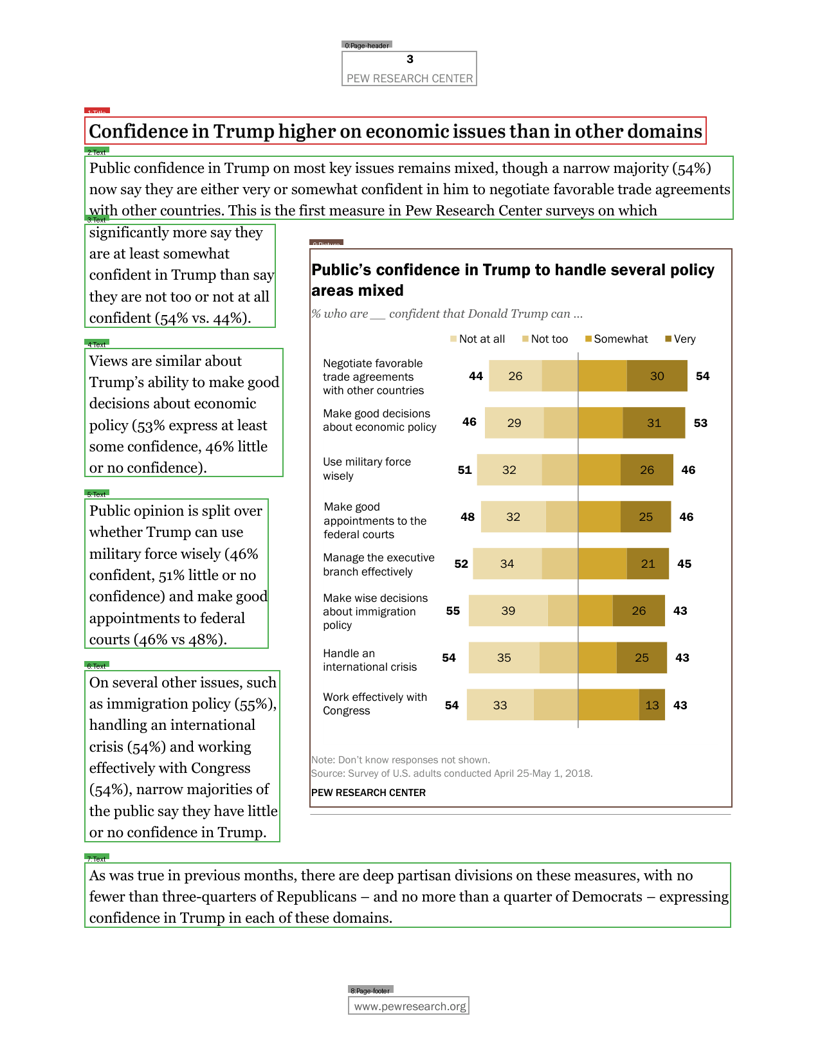

[Specialist] Picture #9   classified as 'Bar Graph'  -> described in 3.2s  (1642 chars)

[social] measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf -- page 11  (multi-picture)
[Architect]  5 blocks in 3.8s  types -> {'Title': 1, 'Page-footer': 1, 'Picture': 3}


**Parse overlay** &mdash; Social-Media Analytics Report (p. 11, modality: multi-picture)

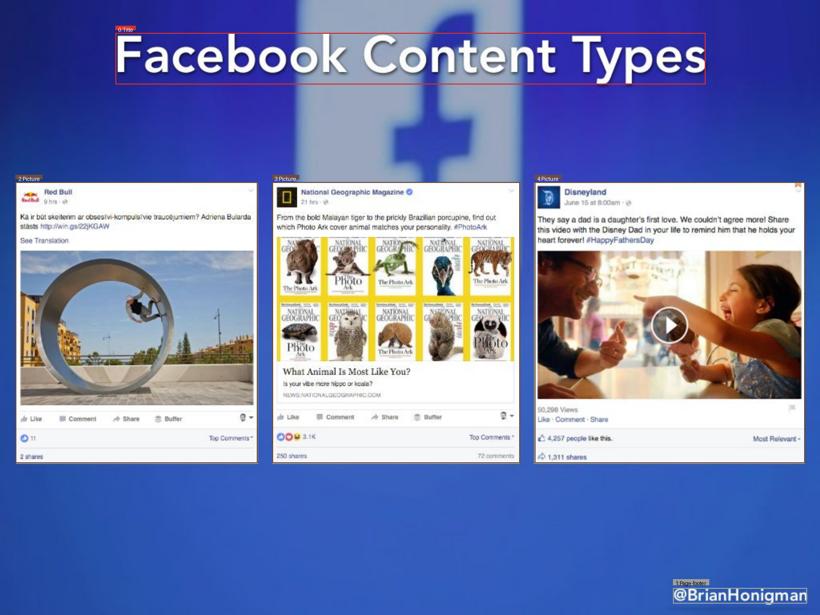

[Specialist] Picture #2   classified as 'Photograph'  -> described in 2.0s  (535 chars)
[Specialist] Picture #3   classified as 'Photograph'  -> described in 2.5s  (981 chars)
[Specialist] Picture #4   classified as 'Photograph'  -> described in 2.5s  (965 chars)

[linkedin] measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf -- page 20  (infographic)
[Architect]  2 blocks in 2.7s  types -> {'Page-footer': 1, 'Picture': 1}


**Parse overlay** &mdash; Social-Media Analytics Report (p. 20, modality: infographic)

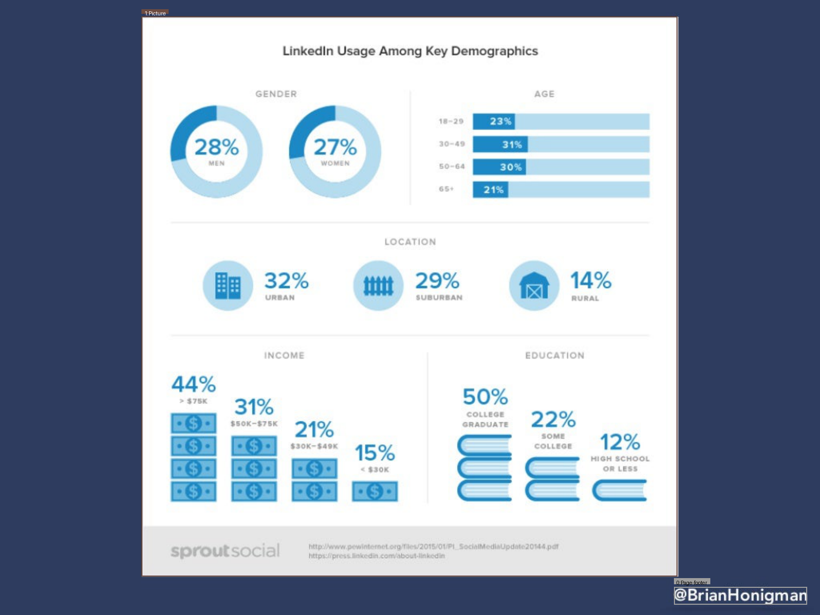

[Specialist] Picture #1   classified as 'Infographic'  -> described in 2.9s  (397 chars)

[gpl] GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf -- page 11  (table)
[Architect]  4 blocks in 3.1s  types -> {'Title': 1, 'Text': 1, 'Page-footer': 1, 'Table': 1}


**Parse overlay** &mdash; Graduate Studies Brochure (p. 11, modality: table)

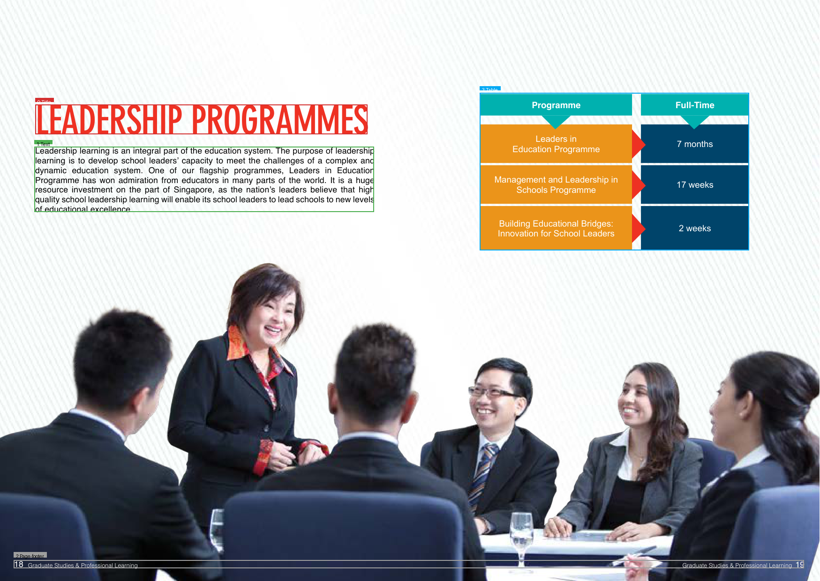

[Specialist] skipped -- no Picture blocks on this page (Parse handled this modality as structured text).

Pipeline finished: 4 pages across 3 documents, 5 pictures transcribed.


In [ ]:
# Per-(short_id, page_n) page images and Parse blocks; per-pdf result bundles
page_images: dict[str, Image.Image] = {}
page_blocks: dict[str, list[dict[str, Any]]] = {}
file_results: dict[str, dict[str, Any]] = {}

# Annotated-preview width (kept small so the notebook file stays lean).
_ANNOT_W = 820

for sid, pdf, page_n, modality in DEMO_DOCS:
    print("\n" + "=" * 74)
    print(f"[{sid}] {pdf.name} -- page {page_n}  ({modality})")
    print("=" * 74)

    page = pdf_page_to_image(pdf, page_n - 1, dpi=150)
    page_images[sid] = page

    # Stage 1 -- Architect.
    t0 = time.time()
    blocks = call_nemotron_parse(page)
    type_counts: dict[str, int] = {}
    for b in blocks:
        type_counts[b.get("type", "?")] = type_counts.get(b.get("type", "?"), 0) + 1
    print(f"[Architect]  {len(blocks)} blocks in {time.time()-t0:.1f}s  "
          f"types -> {type_counts}")
    page_blocks[sid] = blocks

    # Show the coloured layout overlay in-place -- this is the annotated
    # view described in §3.  Annotating a copy keeps sub_type labels out
    # of the overlay until the Specialist runs below.
    annotated = draw_annotations(page, blocks)
    display(Markdown(
        f"**Parse overlay** &mdash; {DISPLAY_NAME[sid]} (p. {page_n}, "
        f"modality: {modality})"))
    display(annotated.resize(
        (_ANNOT_W, int(_ANNOT_W * annotated.height / annotated.width))))

    bundle = file_results.setdefault(
        pdf.name, {"source_filename": pdf.name, "pages": []})
    page_entry: dict[str, Any] = {
        "page_number": page_n, "status": "Layout extraction successful",
        "content": [],
    }

    # Stage 2 -- Visual Specialist for every Picture block.
    n_pics = sum(1 for b in blocks if b.get("type") == "Picture")
    if n_pics == 0:
        print("[Specialist] skipped -- no Picture blocks on this page "
              "(Parse handled this modality as structured text).")

    for i, b in enumerate(blocks):
        item: dict[str, Any] = {
            "extraction_id": i, "type": b.get("type"),
            "bbox": b.get("bbox"), "text": b.get("text"),
        }
        if b.get("type") == "Picture" and b.get("bbox"):
            crop = crop_picture(page, b["bbox"])
            t1 = time.time()
            result = describe_picture(crop)
            sub = result["classification"].get("sub_type", "?")
            print(f"[Specialist] Picture #{i:<2d}  classified as '{sub}'  "
                  f"-> described in {time.time()-t1:.1f}s  "
                  f"({len(result['description'])} chars)")
            b["sub_type"] = sub
            item["classification"] = result["classification"]
            item["description"] = result["description"]
        page_entry["content"].append(item)

    bundle["pages"].append(page_entry)

_n_pics_total = sum(1 for b in file_results.values()
                    for p in b["pages"] for it in p["content"]
                    if it.get("description"))
print("\n" + "=" * 74)
print(f"Pipeline finished: {len(DEMO_DOCS)} pages across "
      f"{len(file_results)} documents, {_n_pics_total} pictures transcribed.")

### 4.3. The roles, recap

The notebook uses **two NVIDIA models** but assigns them **three roles**. The role names are a metaphor: they describe what each call *does*, not what model it is:

| Role | Model | What it does |
|---|---|---|
| **Architect** | `nvidia/nemotron-parse` | Reads the page layout. Returns the bounding boxes, types (`Title`, `Text`, `Picture`, `Table`...), and reading order of every block. |
| **Visual Specialist** | `nvidia/nemotron-3-nano-omni` | For each `Picture` block the Architect found, classifies the picture (`Bar Graph`, `Infographic`, `Photograph`...) and transcribes it with a prompt tailored to that subtype. |
| **Reasoning Engine** | `nvidia/nemotron-3-nano-omni` (same model) | Reads the assembled text + transcriptions and answers your questions, with page citations. |

You only see Architect and Specialist in the output above because §4.2 runs the ingestion pipeline. The Reasoning Engine fires in §7 when you ask questions.

### 4.4. Reading your output, page by page

#### Page 1 — Pew Research, p. 5 (chart)

```
[Architect]  10 blocks  types -> {'Page-header': 1, 'Title': 1, 'Text': 6, 'Page-footer': 1, 'Picture': 1}
[Specialist] Picture #9   classified as 'Bar Graph'  -> described
```

The Architect found 10 layout blocks: a page header, a title, six paragraphs of text, a footer, and **one Picture**. The Specialist then opened that one Picture, looked at it, said "this is a Bar Graph," and produced a Markdown-table transcription of the bar values. Two Specialist calls actually happened here — one to *classify* the picture, one to *transcribe* it — but the log prints one combined Specialist line.

#### Page 2 — Social-Media report, p. 11 (multi-picture)

```
[Architect]  5 blocks  types -> {'Title': 1, 'Page-footer': 1, 'Picture': 3}
[Specialist] Picture #2   classified as 'Photograph'  -> described
[Specialist] Picture #3   classified as 'Photograph'  -> described
[Specialist] Picture #4   classified as 'Photograph'  -> described
```

This is the page that demonstrates the whole point of the architecture. The Architect spotted **three separate Picture blocks** (the three Facebook-post screenshots side by side), and the Specialist then handled each one independently. Because they were isolated up front, the *Disneyland post* in §7 is answerable as a precise number — without that bbox split, a single page-level VLM call would have to juggle all three cards at once and would likely confuse them.

The block indices `#2`, `#3`, `#4` are the Architect's reading-order positions on the page (block 0 was the title, block 1 was the page footer).

#### Page 3 — Social-Media report, p. 20 (infographic)

```
[Architect]  2 blocks  types -> {'Page-footer': 1, 'Picture': 1}
[Specialist] Picture #1   classified as 'Infographic'  -> described
```

The whole page is essentially one rasterized infographic plus a footer. The Architect drew one big `Picture` box around the infographic, the Specialist classified it as `Infographic` (which routes it to a panel-aware transcription prompt), and got a structured Markdown transcription back. Smaller payload than the bar chart because infographics are mostly labels and percentages, not data tables.

#### Page 4 — Graduate Studies brochure, p. 11 (table)

```
[Architect]  4 blocks  types -> {'Title': 1, 'Text': 1, 'Page-footer': 1, 'Table': 1}
[Specialist] skipped -- no Picture blocks on this page (Parse handled this modality as structured text).
```

This is the showcase for the Architect-only modality. The page is a programme-listing table — but Parse recognised it as structured text and emitted it as a **`Table` block** with LaTeX-tabular content, *not* a `Picture`. So no Specialist call was needed at all. The Reasoning Engine in §7 will read the table cells directly.

This is a real cost saving: pages that look table-like to the human eye don't always *need* a vision-language transcription if Parse can read the cells itself.

### 4.5. The summary line

```
Pipeline finished: 4 pages across 3 documents, 5 pictures transcribed.
```

Adding it up: 1 (Pew) + 3 (social) + 1 (linkedin) + 0 (gpl) = **5 pictures transcribed**. The 4 pages came from 3 different PDFs (the social and linkedin pages are from the same PDF). That tally is what gets fed into §7 as queryable context.

### 4.6. What to look at next

- **§5** ("Divide and conquer, modality by modality") shows you the actual *content* the Specialist produced for each picture — the Markdown tables, the transcribed Facebook posts. Worth scrolling through to see what those transcriptions actually look like.
- **§7** is where the Reasoning Engine wakes up and answers questions, citing the page each answer came from.

## 5. Divide and conquer, modality by modality

§4.2 showed the *coloured overlays* — that is, **where** Parse drew
its boxes.  This section shows **what the pair actually produced**
inside each box, one modality at a time.  For every demo page we
pull out:

1. the **exact image crop** Parse handed to the Visual Specialist
   (or the text block if no vision call was needed), and
2. the **Specialist's transcription** of that crop — the text the
   Reasoning Engine will read in §7.

That crop-plus-transcription pair is the *receipt* of the divide-
and-conquer design.  Four modalities, four receipts:

* **Chart** – one `Picture:Bar Graph` box → a clean Markdown table.
* **Multi-picture page** – *three* `Picture` boxes → three separate
  Facebook-post transcriptions (this is the one to linger on — with
  Parse turned off, the single page-level call has to juggle three
  cards at once).
* **Infographic** – one `Picture:Infographic` box → a structured
  panel-by-panel breakdown of the LinkedIn demographic stats.
* **Structured table** – **no `Picture` call at all**: Parse emits
  the programme list directly as a LaTeX-tabular `Table` block the
  Reasoning Engine reads verbatim.

Because the Specialist's transcription is the *same text* the
Reasoning Engine reads in §7, any answer it returns can be
back-traced to one of these crops with one glance.

### Chart &mdash; Pew Research -- Political Release (p. 5)

**Crop #9** &mdash; classified as `Picture:Bar Graph`  
*A bar graph showing public confidence in Donald Trump's ability to handle various policy areas.*

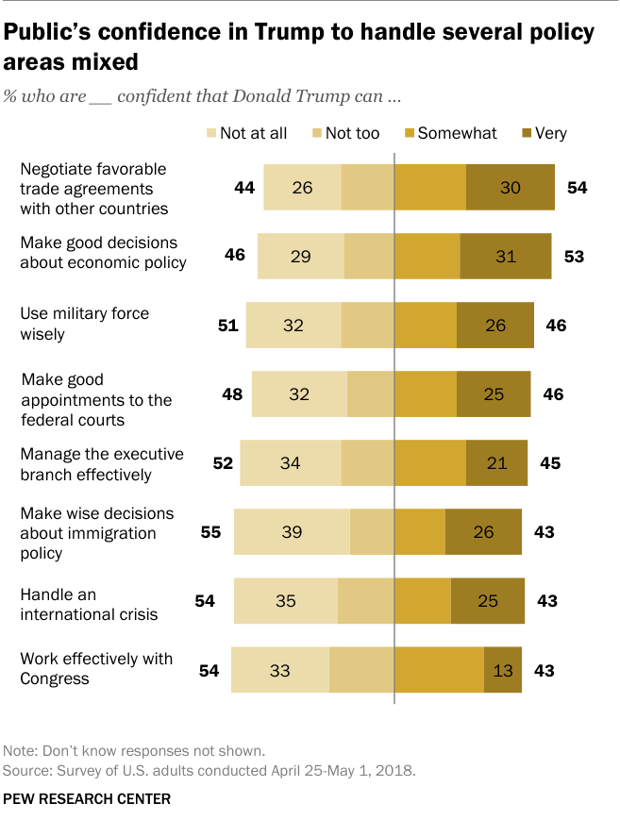

### Transcribed Data

**Title:** Public’s confidence in Trump to handle several policy areas mixed

**Chart Type:** Horizontal stacked bar chart

**X-Axis (Implicit):** Percentage of respondents (% who are __confident that Donald Trump can...)

**Y-Axis (Categories):**
*   Negotiate favorable trade agreements with other countries
*   Make good decisions about economic policy
*   Use military force wisely
*   Make good appointments to the federal courts
*   Manage the executive branch effectively
*   Make wise decisions about immigration policy
*   Handle an international crisis
*   Work effectively with Congress

**Legend:**
*   Not at all (Lightest Beige)
*   Not too (Medium Beige)
*   Somewhat (Gold)
*   Very (Dark Brown)

**Data Values:**

| Category | Not at all | Not too | Somewhat | Very | Total |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Negotiate favorable trade agreements with other countries | 44 | 26 | 30 | 54 | 54 |
| Make good decisions about economic policy | 46 | 29 | 31 | 53 | 53 |
| Use military force wisely | 51 | 32 | 26 | 46 | 46 |
| Make good appointments to the federal courts | 48 | 32 | 25 | 46 | 46 |
| Manage the executive branch effectively | 52 | 34 | 21 | 45 | 45 |
| Make wise decisions about immigration policy | 55 | 39 | 26 | 43 | 43 |
| Handle an international crisis | 54 | 35 | 25 | 43 | 43 |
| Work effectively with Congress | 54 | 33 | 13 | 4

*... (truncated)*

### Multi-Picture &mdash; Social-Media Analytics Report (p. 11)

**Crop #2** &mdash; classified as `Picture:Photograph`  
*A person is performing a parkour move by climbing through a large circular metal sculpture in an urban setting.*

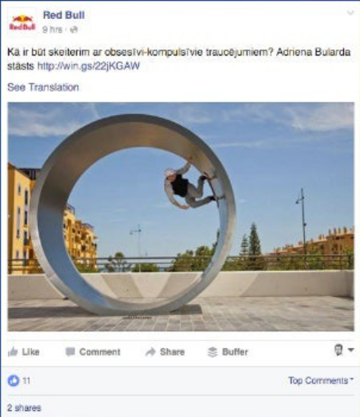

The image shows a person in mid-air, performing a parkour move by jumping through a large, circular, metallic sculpture. The person is wearing a white shirt, dark pants, and a cap. The background features a clear blue sky, a few buildings, and some greenery. The text visible in the image includes "Red Bull" at the top left corner, a question in a foreign language, a URL, and "See Translation" below the image. The bottom of the image has options to "Like," "Comment," "Share," and "Buffer," along with "2 shares" and "Top Comments."

**Crop #3** &mdash; classified as `Picture:Photograph`  
*A National Geographic Magazine Facebook post featuring a grid of animal-themed magazine covers and a caption asking which animal matches the viewer's personality.*

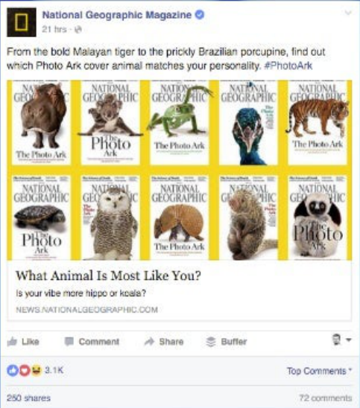

The image is a screenshot of a Facebook post from the National Geographic Magazine page. The post features a grid of ten images, each depicting a different animal on the cover of a National Geographic magazine. The animals include a Malayan tiger, a porcupine, a hippo, a koala, a lion, a giraffe, a zebra, a panda, a bear, and a dog. Each cover has the National Geographic logo at the top and the title "The Photo Ark" at the bottom. The color scheme of the covers varies, with each animal cover featuring vibrant colors that correspond to the animal's natural hues. The text above the grid reads, "From the bold Malayan tiger to the prickly Brazilian porcupine, find out which Photo Ark cover animal matches your personality. #PhotoArk." Below the grid, there is a question, "What Animal Is Most Like You?" followed by a prompt, "Is your vibe more hippo or koala?" The post has received 250 shares and 72 comments, as indicated by the icons and numbers at the bottom of the post.

**Crop #4** &mdash; classified as `Picture:Photograph`  
*A father and daughter playfully interacting while sharing ice cream.*

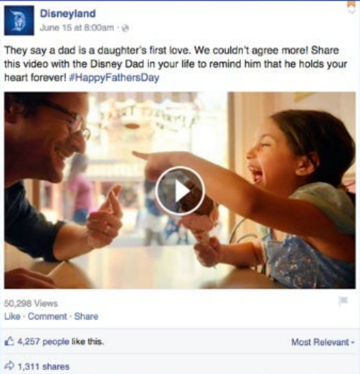

The image is a screenshot of a Facebook post from the Disneyland page. The post includes a video thumbnail with a still image from the video. The image shows a man and a young girl sitting across from each other at a table. The man is wearing glasses and a dark-colored shirt, and he is smiling while looking at the girl. The girl is pointing her finger at the man, and she is smiling with her mouth open, suggesting laughter or excitement. The background is blurred, but it appears to be an indoor setting with natural light coming from the windows.

The text on the post reads: "They say a dad is a daughter's first love. We couldn't agree more! Share this video with the Disney Dad in your life to remind him that he holds your heart forever! #HappyFathersDay". The post was made on June 15 at 8:00 am and has garnered 50,298 views, 4,257 likes, and 1,311 shares. The post also indicates that 4,257 people like this, and the shares are sorted by "Most Relevant."

### Infographic &mdash; Social-Media Analytics Report (p. 20)

**Crop #1** &mdash; classified as `Picture:Infographic`  
*The image is an infographic titled 'LinkedIn Usage Among Key Demographics' that presents statistical data on LinkedIn users across various categories including gender, age, location, income, and education.*

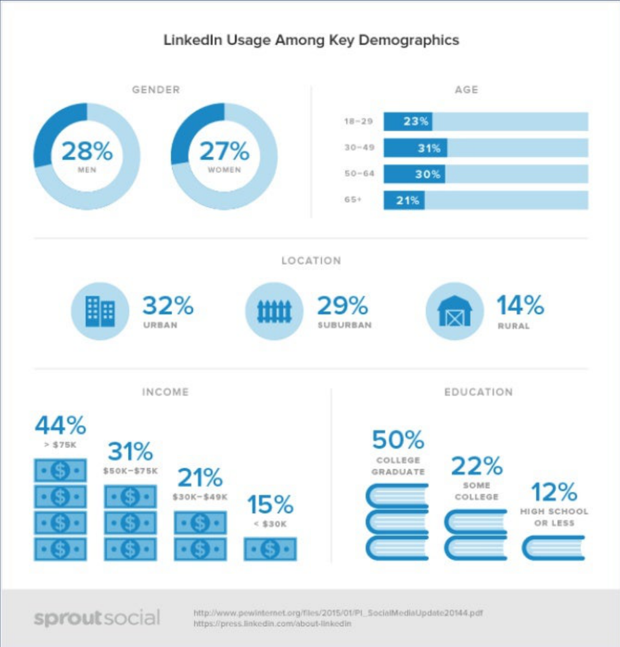

# LinkedIn Usage Among Key Demographics

## Gender
- **28% MEN**
- **27% WOMEN**

## Age
- **18-29**: 23%
- **30-49**: 31%
- **50-64**: 30%
- **65+**: 21%

## Location
- **32% URBAN**
- **29% SUBURBAN**
- **14% RURAL**

## Income
- **44%** > $75K
- **31%** $50K-$75K
- **21%** $30K-$49K
- **15%** < $30K

## Education
- **50% COLLEGE GRADUATE**
- **22% SOME COLLEGE**
- **12% HIGH SCHOOL OR LESS**

### Table &mdash; Graduate Studies Brochure (p. 11)

Parse surfaced this region as a `Table` block with LaTeX-tabular body &mdash; **no Visual Specialist call was needed**.  The Reasoning Engine reads the cells below as plain text:

\begin{tabular}{cc}
**Programme** & **Full-Time**\\
Leaders in Education Programme & 7 months\\
Management and Leadership in Schools Programme & 17 weeks\\
Building Educational Bridges: Innovation for School Leaders & 2 weeks\\
\end{tabular}


In [ ]:
# Per-modality evidence: the crop(s) Parse isolated + the Visual
# Specialist's transcription.  We do NOT re-display full annotated
# pages here -- those live in §4.2.  The page image itself is
# shown only to provide the crop; transcriptions are rendered as
# Markdown so tables come out formatted.
MAX_DESC_CHARS = 1400

for sid, pdf, page_n, modality in DEMO_DOCS:
    display(Markdown(
        f"### {modality.title()} &mdash; {DISPLAY_NAME[sid]} (p. {page_n})"
    ))

    page = page_images[sid]
    blocks = page_blocks[sid]
    page_entry = next(p for p in file_results[pdf.name]["pages"]
                      if p["page_number"] == page_n)

    pic_items = [it for it in page_entry["content"]
                 if it.get("type") == "Picture" and it.get("description")]
    tab_items = [it for it in page_entry["content"]
                 if it.get("type") == "Table" and it.get("text")]

    # Structured-table case: Parse handled it directly; no vision
    # call was required.
    if not pic_items and tab_items:
        display(Markdown(
            "Parse surfaced this region as a `Table` block with "
            "LaTeX-tabular body &mdash; **no Visual Specialist call "
            "was needed**.  The Reasoning Engine reads the cells "
            "below as plain text:"))
        print(tab_items[0]["text"])
        continue

    block_by_id = {i: b for i, b in enumerate(blocks)}
    crop_w = 360 if len(pic_items) > 1 else 620

    for item in pic_items:
        block = block_by_id[item["extraction_id"]]
        cls = item["classification"] or {}
        sub = cls.get("sub_type", "?")
        subject = cls.get("subject_matter", "")
        header = (f"**Crop #{item['extraction_id']}** &mdash; "
                  f"classified as `Picture:{sub}`")
        if subject:
            header += f"  \n*{subject}*"
        display(Markdown(header))

        crop = crop_picture(page, block["bbox"])
        display(crop.resize((crop_w,
                             int(crop_w * crop.height / crop.width))))

        desc = item["description"]
        if len(desc) > MAX_DESC_CHARS:
            desc = desc[:MAX_DESC_CHARS].rstrip() + "\n\n*... (truncated)*"
        display(Markdown(desc))

## 6. Examining the final JSON output

The pipeline fuses both models' results into a single, structured
JSON object *per document*.  Every page carries a list of `content`
items; `Picture` items contain the Visual Specialist's
`classification` (image type, sub-type, subject-matter summary)
alongside its textual `description`, while `Table` items carry the
LaTeX-tabular text Parse emitted directly.

This JSON is the *only* artifact the Reasoning Engine needs. It
can be serialised, cached, re-queried, or piped into downstream
retrieval systems.  Below we preview the Pew Research document's
output and save one `<stem>.parse_omni.json` per PDF to disk.

In [ ]:
# Preview the shortest bundle (the Pew one-pager) so the reader
# sees the full shape on screen without scrolling.
_preview_pdf_name = DEMO_DOCS[0][1].name  # Pew Research release
_preview = file_results[_preview_pdf_name]
print(f"=== preview: {_preview_pdf_name} ===")
for line in json.dumps(_preview, indent=2, default=str).split("\n")[:60]:
    print(line)
print("... (truncated)\n")

# Save one JSON per PDF.  Downstream retrieval systems can index these
# directly, one embedding per page.
OUTPUT_DIR = NOTEBOOK_ROOT / "output_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for pdf_name, bundle in file_results.items():
    out = OUTPUT_DIR / (Path(pdf_name).stem + ".parse_omni.json")
    out.write_text(json.dumps(bundle, indent=2, default=str))
    print(f"  saved  {out.name}  ({len(bundle['pages'])} page(s))")

=== preview: 05-03-18-political-release.pdf ===
{
  "source_filename": "05-03-18-political-release.pdf",
  "pages": [
    {
      "page_number": 5,
      "status": "Layout extraction successful",
      "content": [
        {
          "extraction_id": 0,
          "type": "Page-header",
          "bbox": {
            "xmin": 0.41702274509803916,
            "ymin": 0.04807466666666666,
            "xmax": 0.5811764705882353,
            "ymax": 0.0810909090909091
          },
          "text": "3 PEW RESEARCH CENTER"
        },
        {
          "extraction_id": 1,
          "type": "Title",
          "bbox": {
            "xmin": 0.10280407843137254,
            "ymin": 0.11013527272727273,
            "xmax": 0.8614010980392156,
            "ymax": 0.13632484848484847
          },
          "text": "## Confidence in Trump higher on economic issues than in other domains"
        },
        {
          "extraction_id": 2,
          "type": "Text",
          "bbox": {
            "xm

## 7. Querying the document with the Reasoning Engine

With every page distilled into a picture-transcribed,
spatially-ordered context, we can ask real questions.  The *same*
Nano Omni model we used as Visual Specialist now puts on its
**Reasoning Engine** hat and answers. We cite the page and quote
the supporting phrase for every answer.

We pose one question per modality; each answer is visible on the
Parse overlay in §4.2, so you can verify it by eye:

1. **Chart (Pew Research, p. 5).**  Which policy area draws the
   largest share of *very* confident respondents?  A stacked-bar
   chart question that only works because the Specialist turned the
   chart into a Markdown table first.
2. **Multi-picture (Social-Media report, p. 11).**  *"How many
   likes does the Disneyland post have?"*  Three Facebook-post
   screenshots sit side by side on the page; with Parse turned off,
   a single page-level VLM call would have to pick the right card
   while reading it.  Parse's three separate `Picture` boxes make
   the answer surgical.
3. **Infographic (Social-Media report, p. 20).**  *"What percentage
   of LinkedIn users have household income above $75K?"*  The digit
   lives inside one panel of a pixel-only demographic infographic.
4. **Structured table (Graduate Studies brochure, p. 11).**  *"Which
   leadership programme has the longest Full-Time duration?"*  Pure
   Architect work — Parse preserved the programme/duration table as
   LaTeX-tabular text so the Reasoning Engine can scan it without a
   vision call.

In [ ]:
# Per-document context: each PDF we processed gets its own assembled
# context string, stitched together from the pages we ran through
# the pipeline, with strong page delimiters so citations land on the
# right page number.
doc_contexts: dict[str, str] = {}
for sid, pdf, page_n, _mod in DEMO_DOCS:
    entry = next(p for p in file_results[pdf.name]["pages"]
                 if p["page_number"] == page_n)
    descs = [it["description"] for it in entry["content"]
             if it.get("type") == "Picture" and it.get("description")]
    chunk = assemble_page_context(page_blocks[sid], descs, page_n=page_n)
    doc_contexts.setdefault(pdf.name, []).append(chunk)

for pdf_name, chunks in doc_contexts.items():
    merged = "\n\n".join(chunks)
    doc_contexts[pdf_name] = merged
    print(f"context: {pdf_name}  -> {len(merged):,} chars, "
          f"{len(chunks)} page(s)")
print()

# One question per demo page, routed to the doc whose context can
# answer it.  (short_id, question)
qa_plan: list[tuple[str, str]] = [
    ("pew",
     "Which policy area has the largest share of respondents who are "
     "'very' confident in Donald Trump? Give the policy phrase and the "
     "percentage."),
    ("social",
     "How many people like the Disneyland post?"),
    ("linkedin",
     "What percentage of LinkedIn users have a household income above "
     "$75K?"),
    ("gpl",
     "Among the leadership programmes listed, which programme has the "
     "longest Full-Time duration, and what is that duration?"),
]

# Each question fires a single Reasoning Engine call scoped to the
# document it belongs to, so citations point at the right page.
sid_to_pdf = {sid: pdf.name for sid, pdf, _, _ in DEMO_DOCS}
for sid, q in qa_plan:
    pdf_name = sid_to_pdf[sid]
    context = doc_contexts[pdf_name]
    print("=" * 74)
    print(f"DOC:      {DISPLAY_NAME[sid]}  ({pdf_name})")
    print(f"QUESTION: {q}")
    t0 = time.time()
    answer = ask_question(q, context)
    print(f"[{time.time()-t0:.1f}s]")
    display(Markdown(f"**ANSWER:**\n\n{answer}"))
    print()

context: 05-03-18-political-release.pdf  -> 3,029 chars, 1 page(s)
context: measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf  -> 3,116 chars, 2 page(s)
context: GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf  -> 956 chars, 1 page(s)

DOC:      Pew Research -- Political Release  (05-03-18-political-release.pdf)
QUESTION: Which policy area has the largest share of respondents who are 'very' confident in Donald Trump? Give the policy phrase and the percentage.
[5.4s]


**ANSWER:**

Negotiate favorable trade agreements with other countries 54% (p. 5)


DOC:      Social-Media Analytics Report  (measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf)
QUESTION: How many people like the Disneyland post?
[4.9s]


**ANSWER:**

"4,257 likes" (p. 11)


DOC:      Social-Media Analytics Report  (measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf)
QUESTION: What percentage of LinkedIn users have a household income above $75K?
[4.9s]


**ANSWER:**

44% (p. 20) "44% > $75K"


DOC:      Graduate Studies Brochure  (GPL-Graduate-Studies-Professional-Learning-Brochure-Jul-2021.pdf)
QUESTION: Among the leadership programmes listed, which programme has the longest Full-Time duration, and what is that duration?
[2.2s]


**ANSWER:**

Leaders in Education Programme, "7 months" (p. 11)

## 8. The four structural challenges, demonstrated

The intro section claimed Parse solves four structural problems that
Nano Omni alone cannot: structured tables, chart isolation,
multi-picture pages, and citation anchoring. Now that the pipeline
has run, every variable we need is in scope (`page_images`,
`page_blocks`, `doc_contexts`, `sid_to_pdf`, plus `ask_question`,
`call_nano_omni`, `extract_text`, `crop_picture`,
`draw_annotations`). The four cells below run a real before/after
for each claim against the same model, the same prompt, and the
same hosted endpoint, so the only variable is whether Parse's
spatial layer fed the call or not.


### 8.1. Tables and headers need structure, not pixels

The Graduate Studies brochure (`gpl`, p. 11) carries a programme/
duration table embedded in a glossy marketing layout. Parse
serialises that region as a `Table` block whose body is
LaTeX-tabular. The Reasoning Engine reads it as plain text, so we
can answer *"which programme has the longest Full-Time duration?"*
by feeding the table text alone into `ask_question`. Zero vision
calls, zero crop work.


In [ ]:
# CASE 1 — Structured table, text-only QA.
# Build a context that contains ONLY the LaTeX table from Parse;
# no surrounding prose, no picture transcriptions, no page image.

gpl_blocks = page_blocks["gpl"]
gpl_tables = [b for b in gpl_blocks if b.get("type") == "Table"]
print(f"Parse found {len(gpl_tables)} Table block(s) on gpl p. 11.")

display(Markdown("**Parse `Table` block — raw LaTeX-tabular body (first 900 chars):**"))
print(gpl_tables[0]["text"][:900])

# Frame as page 11 so the citation in the answer lands correctly.
table_only_ctx = (
    "===== PAGE 11 =====\n\n"
    + gpl_tables[0]["text"]
    + "\n\n===== END PAGE 11 ====="
)

q = (
    "Among the leadership programmes listed, which programme has the "
    "longest Full-Time duration, and what is that duration?"
)
display(Markdown(f"**Q.** {q}"))
display(Markdown("**A.** (text-only QA, zero vision calls)"))
display(Markdown(ask_question(q, table_only_ctx)))


Parse found 1 Table block(s) on gpl p. 11.


**Parse `Table` block — raw LaTeX-tabular body (first 900 chars):**

\begin{tabular}{cc}
**Programme** & **Full-Time**\\
Leaders in Education Programme & 7 months\\
Management and Leadership in Schools Programme & 17 weeks\\
Building Educational Bridges: Innovation for School Leaders & 2 weeks\\
\end{tabular}


**Q.** Among the leadership programmes listed, which programme has the longest Full-Time duration, and what is that duration?

**A.** (text-only QA, zero vision calls)

Leaders in Education Programme, 7 months (p. 11) "7 months"

### 8.2. A chart region needs isolation before transcription

The Pew Research page (`pew`, p. 5) has a stacked bar chart sitting
next to four prose paragraphs. We send Nano Omni the same prompt
twice: once with the whole page, once with the Parse-isolated
`Picture` crop. The crop version returns a clean eight-row markdown
table. The whole-page version has to share its attention between
chart pixels and body copy, and the table that comes back shows it.


**A. Full page → Nano Omni** (no Parse isolation)

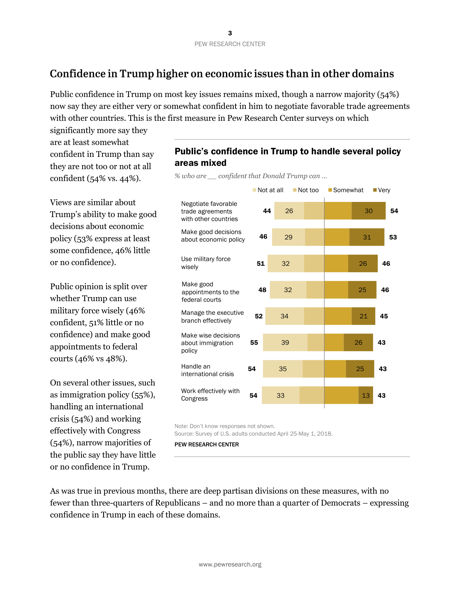

| Negotiate favorable trade agreements with other countries | 44 | 26 | 30 | 54 |
| --- | --- | --- | --- | --- |
| Make good decisions about economic policy | 46 | 29 | 31 | 53 |
| Use military force wisely | 51 | 32 | 26 | 46 |
| Make good appointments to the federal courts | 48 | 32 | 25 | 46 |
| Manage the executive branch effectively | 52 | 34 | 21 | 45 |
| Make wise decisions about immigration policy | 55 | 39 | 26 | 43 |
| Handle an international crisis | 54 | 35 | 25 | 43 |
| Work effectively with Congress | 54 | 33 | 13 | 43 |

**B. Parse-isolated `Picture:Bar Graph` crop → Nano Omni** (the pipeline path)

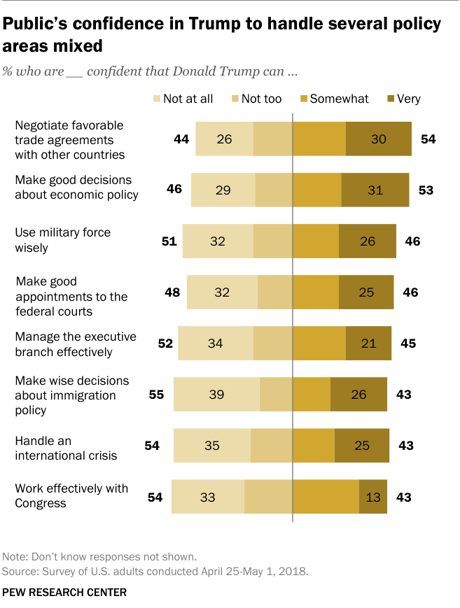

{'type': 'type': 'text', 'text': 'Answer directly and concis not include any reasoning, preamble, or  Vis blocks. 
'text': 'Answer directly and concisely. Do NOT include any reasoning, preamble, or  Vis blocks.'  Vis 
'type': 'text', 'text': 'Answer directly and concis. 
'text': 'Answer directly and concis. 
'text': 'Answer directly and concis. Do NOT include any reasoning, preamble, or  Vis 
'text': 'text', '| Negotiate favorable trade agreements with other countries | 44 | 26 | | 30 | 54 | Make good decisions about economic policy | 46 | 29 | | 31 | 53 | 'Use military force wisely': '51', '32': '', '26': '46', 'Make good appointments to the federal courts': '48', '32': '32', '25': '46', 'Manage the executive branch effectively': '52', '34': '', '21': '45', 'Make wise decisions about immigration policy': '55', '39': '', '26': '43', 'Handle an international crisis': '54', '35': '', '25': '43', 'Work effectively with Congress': '54', '33': '', '13': '43'}

In [ ]:
# CASE 2 — Same prompt, two inputs: full page vs. Parse crop.

pew_page = page_images["pew"]
pew_blocks = page_blocks["pew"]
chart_block = next(b for b in pew_blocks if b.get("type") == "Picture")

prompt = (
    "Transcribe the bar chart on this image as a markdown table. "
    "Include every category row and every numeric value visible. "
    "Do not include any surrounding prose."
)

# A — whole page
display(Markdown("**A. Full page → Nano Omni** (no Parse isolation)"))
display(pew_page.resize((460, int(460 * pew_page.height / pew_page.width))))
full_resp = call_nano_omni(
    prompt, images=[pew_page],
    reasoning="off", temperature=0.0, max_tokens=1024,
)
display(Markdown(extract_text(full_resp)))

# B — Parse-isolated crop (the pipeline path)
display(Markdown(
    "**B. Parse-isolated `Picture:Bar Graph` crop → Nano Omni** "
    "(the pipeline path)"
))
chart_crop = crop_picture(pew_page, chart_block["bbox"])
display(chart_crop.resize(
    (460, int(460 * chart_crop.height / chart_crop.width))
))
crop_resp = call_nano_omni(
    prompt, images=[chart_crop],
    reasoning="off", temperature=0.0, max_tokens=1024,
)
display(Markdown(extract_text(crop_resp)))


### 8.3. Multi-picture pages bleed together

The social-media report page 11 (`social`) packs three Facebook-post
screenshots in a single row: Red Bull, National Geographic, and
Disneyland. We ask the same question — *"How many likes does the
Disneyland post have?"* — first against the whole page, then once
per Parse-isolated crop. With three crops on screen the model has
to decide *which* card the question is about before it can read it;
on a single crop it just reads.


Parse found 3 Picture blocks on social p. 11.


**A. Full page → Nano Omni**

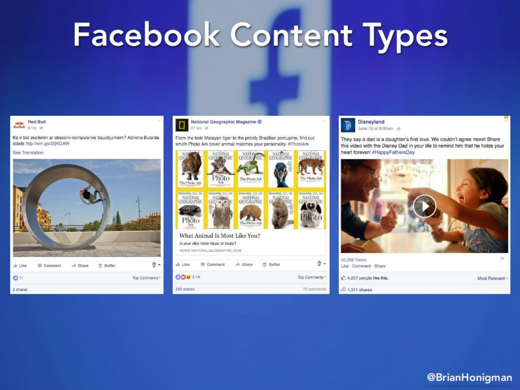

**Answer:** 4,257

**B. Each Parse-isolated crop, asked in turn** (only one crop is the Disneyland post)

**Crop #0** (`Picture:Photograph`) → not this one

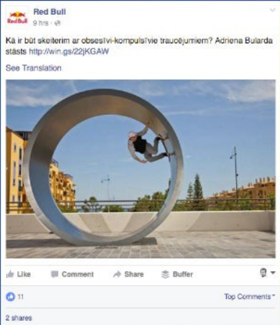

**Crop #1** (`Picture:Photograph`) → We need to see if the screenshot is a Disneyland post. It's not; it's National Geographic Magazine. So we must reply exactly 'not this one' as per instruction: "If this screenshot is not the Disneyland post, reply with exactly 'not this one'." So answer: not this one

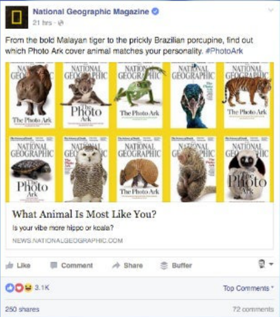

**Crop #2** (`Picture:Photograph`) → 4,257

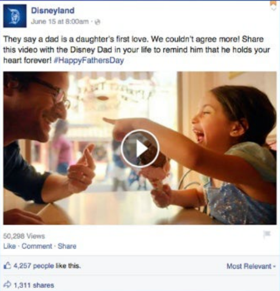

In [ ]:
# CASE 3 — Multi-picture: full page vs. one-crop-at-a-time.

social_page = page_images["social"]
social_blocks = page_blocks["social"]
pic_blocks = [b for b in social_blocks if b.get("type") == "Picture"]
print(f"Parse found {len(pic_blocks)} Picture blocks on social p. 11.")

q = "How many likes does the Disneyland post have?"

# A — whole page
display(Markdown("**A. Full page → Nano Omni**"))
display(social_page.resize(
    (520, int(520 * social_page.height / social_page.width))
))
full_resp = call_nano_omni(
    q, images=[social_page],
    reasoning="off", temperature=0.0, max_tokens=256,
)
display(Markdown(f"**Answer:** {extract_text(full_resp)}"))

# B — one Parse crop at a time, same question
display(Markdown(
    "**B. Each Parse-isolated crop, asked in turn** "
    "(only one crop is the Disneyland post)"
))
for i, b in enumerate(pic_blocks):
    crop = crop_picture(social_page, b["bbox"])
    sub = b.get("sub_type", "?")
    crop_q = (
        q
        + "  If this screenshot is not the Disneyland post, "
          "reply with exactly 'not this one'."
    )
    resp = call_nano_omni(
        crop_q, images=[crop],
        reasoning="off", temperature=0.0, max_tokens=64,
    )
    display(Markdown(
        f"**Crop #{i}** (`Picture:{sub}`) → {extract_text(resp)}"
    ))
    display(crop.resize((280, int(280 * crop.height / crop.width))))


### 8.4. Citations need anchors

Every answer the Reasoning Engine returns carries a `(p. N)` cite
and a verbatim quote from the assembled context. With Parse's bbox
+ reading-order index attached to every block, that quote is more
than text — it is a coordinate on the page image. Below we ask a
question against the LinkedIn infographic context (p. 20), pull the
quoted phrase out of the answer, find the Parse block whose text
contains it, and draw that block's bbox on the original page.
Answer → phrase → bbox → pixel.


In [ ]:
# CASE 4 — From answer to quoted phrase to drawn bbox.

q = (
    "What percentage of LinkedIn users have a household income "
    "above $75K?"
)
linkedin_pdf = sid_to_pdf["linkedin"]
answer = ask_question(q, doc_contexts[linkedin_pdf])
display(Markdown(f"**Q.** {q}"))
display(Markdown(f"**A.** {answer}"))

# Pull the first quoted phrase out of the answer.  The QA prompt
# tells the Reasoning Engine to quote verbatim, so a quote should
# be there.
m = re.search(r'["\u201c](.+?)["\u201d]', answer)
#if not m:
#    raise RuntimeError(
#        "No quoted phrase in the answer; rerun the cell."
#    )
quote = m.group(1).strip()
print(f"\nQuoted phrase pulled from the answer: {quote!r}")


def find_supporting_block(blocks, phrase):
    """Locate the Parse block whose text contains the quote.

    Falls back to a numeric-token match if the exact substring is
    missing (Specialist transcription wording can drift one token).
    """
    p = phrase.lower()
    for b in blocks:
        if p in (b.get("text") or "").lower():
            return b
    nums = re.findall(r"\d+%?", phrase)
    if nums:
        for b in blocks:
            t = b.get("text") or ""
            if all(n in t for n in nums):
                return b
    return None


target = find_supporting_block(page_blocks["linkedin"], quote)
if target is None:
    # The phrase came from the Specialist's transcription, not from a
    # text block.  Fall back to the largest Picture block on the page
    # (the infographic itself), which is the bbox the answer is
    # really pointing at.
    target = max(
        (b for b in page_blocks["linkedin"]
         if b.get("type") == "Picture"),
        key=lambda b: (
            (b["bbox"]["xmax"] - b["bbox"]["xmin"])
            * (b["bbox"]["ymax"] - b["bbox"]["ymin"])
        ),
    )
    print(
        "(phrase not in a Parse text block — falling back to the "
        "containing infographic Picture block)"
    )

page = page_images["linkedin"]
overlay = draw_annotations(page, [target])
display(Markdown(
    f"**Citation anchor.**  bbox `{target['bbox']}` on p. 20 "
    f"(type `{target.get('type')}`)."
))
display(overlay.resize(
    (560, int(560 * overlay.height / overlay.width))
))


**Q.** What percentage of LinkedIn users have a household income above $75K?

**A.** 44% (p. 20)

RuntimeError: No quoted phrase in the answer; rerun the cell.

## 9. Next steps

This pipeline fits on one page and covers every modality a real
PDF throws at you (text, tables, charts, infographics, UI
screenshots) — on a single, consistent Nano Omni surface — because
Nano Omni's long-context reasoning can hold a ~25-page document's
worth of assembled context in one call.

A few directions to take it from here:

- **Try it on your documents.**  Extend `DEMO_DOCS` in §3 with any
  `(short_id, pdf, page, modality)` tuples you like and re-run.
  Pages that are rasterised images (scanned reports, marketing
  decks, social-media screenshots, dashboards) are the pipeline's
  sweet spot — they are also exactly the pages most text-first
  parsers drop on the floor.
- **Batch the picture stage when quota is tight.**  For
  picture-dense documents (dashboards, slide decks, screenshot
  catalogues), you can send every picture on a page in a single
  multi-image Nano Omni call and ask for one JSON entry per
  picture.  This trades a little peak quality for roughly 4×
  fewer picture-stage API calls on picture-dense pages; use it
  when API-quota economics matter more than peak accuracy.
- **Scale past ~25 pages with long-context retrieval.**  The
  per-document JSON written in §6 is a ready-made input for a
  vector store: one embedding per page, retrieve the top-k at
  question time, and feed those pages' `assemble_page_context`
  strings straight into the Reasoning Engine.  Parse's reading
  order + bbox anchors survive retrieval, so the model can still
  cite the right page.
- **Customise the picture-stage prompts.**  The `ANALYSIS_PROMPTS`
  dispatch table in §4.1 is the single place where you teach the
  pipeline what a *good* transcription looks like for your domain
  — product photos, engineering drawings, medical charts, CAD
  screenshots.  Adding a new entry is three lines of code.

Two NVIDIA models.  Three roles.  One model surface for both
"what does this picture mean" and "what is the user actually
asking" — that is the all-modality foundation this cookbook sells.

## 10. Addendum: Self-hosting

Both models ship as NVIDIA Inference Microservices (NIMs) on [NVIDIA GPU Cloud](https://www.nvidia.com/en-us/gpu-cloud/). The **Deploy** tab on each model card has copy-paste vLLM, SGLang, and TensorRT-LLM launch commands ([Parse · Deploy](https://build.nvidia.com/nvidia/nemotron-parse/deploy), [Nano Omni · Deploy](https://build.nvidia.com/nvidia/nemotron-3-nano-omni-30b-a3b-reasoning/deploy)). Open weights are also available on Hugging Face in BF16, FP8, and NVFP4.
* [Nemotron Parse 1.2](https://huggingface.co/nvidia/NVIDIA-Nemotron-Parse-v1.2)
* [Nemotron 3 Omni Nano](https://huggingface.co/nvidia/Nemotron-3-Nano-Omni-30B-A3B-Reasoning-BF16)
Tested hardware: H100, B200, DGX Spark, RTX Pro 6000, Jetson Thor.
